# CAMS: Dust Aerosol over West Africa

---

## Learning objectives

1. Access the Copernicus Atmosphere Monitoring Service (CAMS) via the Atmosphere Data Store (ADS)
2. Understand the difference between ADS and CDS: same client, different endpoint
3. Download EAC4 atmospheric reanalysis: dust aerosol optical depth
4. Plot dust AOD over West Africa and identify major dust events
5. Understand how dust forecasts feed into health early warning systems

---

## Introduction

**CAMS** (Copernicus Atmosphere Monitoring Service) provides global atmospheric composition
data: air quality, aerosols, greenhouse gases, and more. It is managed by ECMWF.

**Dust storms** are a priority SEWA hazard for **Western Africa**: affecting health,
aviation, and agriculture across the Sahel. The Bodélé Depression (Chad) is one of
the world's largest dust sources.

**EAC4** is the CAMS global reanalysis: the atmosphere equivalent of ERA5.
It covers 2003-present at 0.75° resolution, 3-hourly.

### Access path

CAMS data is on the **Atmosphere Data Store (ADS)**: same `cdsapi` client as CDS,
just a different URL:

```
# CDS (climate data)
url: https://cds.climate.copernicus.eu/api

# ADS (atmosphere data)
url: https://ads.atmosphere.copernicus.eu/api
```

You need a **separate free ADS account** at [ads.atmosphere.copernicus.eu](https://ads.atmosphere.copernicus.eu).
Your CDS token does NOT work on ADS.

> **Prerequisites:** Free ADS account + personal access token  
> Register at [ads.atmosphere.copernicus.eu](https://ads.atmosphere.copernicus.eu)  
> **Run time:** ~3 min first run (~10 MB), instant on subsequent runs  


## 1) Setup

We use **earthkit.data** with the `"ads"` source: same API as `"cds"` for ERA5,
just pointing to the Atmosphere Data Store instead of the Climate Data Store.

**Prerequisites:**
- ADS account (free, separate from CDS): [ads.atmosphere.copernicus.eu](https://ads.atmosphere.copernicus.eu)
- API key saved in `~/.adsapirc` (shown on your ADS profile page)

> **Native API:** `cdsapi` also works for ADS by passing the ADS URL explicitly.
> We show it as a commented alternative below.
> earthkit's `ekd.from_source("ads", ...)` is cleaner and consistent with the rest of the series.


In [21]:
import earthkit.data as ekd
import cdsapi  # used by earthkit internally; kept for reference
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

from _utils import get_data_dir
DATA_DIR = get_data_dir()
print('Data cache:', DATA_DIR)
print('earthkit-data:', ekd.__version__)


Data cache: /Users/valtze/ecmwf-open-data-guide/data
earthkit-data: 0.19.4


## 2) Download EAC4: dust aerosol optical depth

We fetch dust AOD at 550nm over West Africa for March 2024: a typical peak dust season month when Saharan dust transport is active.

**Dust AOD at 550nm:** a measure of how much dust is in the atmospheric column.
Values >0.5 indicate heavy dust loading; >1.0 indicate very dense dust events.

**First run:** downloads ~10 MB from ADS  
**Subsequent runs:** loads from cache instantly


In [22]:
dust_path = DATA_DIR / 'cams_eac4_dust_aod_westafrica_mar2024.grib'

if not dust_path.exists():
    print('Downloading CAMS EAC4 dust AOD via earthkit... (~3 min first run)')
    ds_dust = ekd.from_source(
        'ads',
        'cams-global-reanalysis-eac4',
        {
            'variable': 'dust_aerosol_optical_depth_550nm',
            'date': '2024-03-01/2024-03-31',
            'time': ['00:00', '06:00', '12:00', '18:00'],
            'area': [35, -20, 5, 40],   # West Africa / Sahel
            'format': 'grib',
        }
    )
    ds_dust.save(str(dust_path))
    print(f'Saved: {dust_path.name} ({dust_path.stat().st_size/1e6:.1f} MB)')
else:
    print(f'Cached: {dust_path.name} ({dust_path.stat().st_size/1e6:.1f} MB)')

# ── Alternative: native cdsapi with ADS URL ───────────────────────────────────
# import cdsapi
# ads = cdsapi.Client(url='https://ads.atmosphere.copernicus.eu/api')
# ads.retrieve('cams-global-reanalysis-eac4',
#     {'variable': 'dust_aerosol_optical_depth_550nm',
#      'date': '2024-03-01/2024-03-31',
#      'time': ['00:00', '06:00', '12:00', '18:00'],
#      'area': [35, -20, 5, 40], 'format': 'grib'},
#     str(dust_path))
# cdsapi is the native ADS/CDS client - earthkit uses it internally via ~/.adsapirc.
# Use cdsapi directly if you need more control or want to avoid earthkit.


Cached: cams_eac4_dust_aod_westafrica_mar2024.grib (1.2 MB)


## 3) Inspect and plot: monthly mean dust AOD


In [23]:
ds = ekd.from_source('file', str(dust_path))
print(ds.ls())


    centre shortName typeOfLevel  level  dataDate  dataTime stepRange  \
0     ecmf  duaod550     surface      0  20240301         0         0   
1     ecmf  duaod550     surface      0  20240301       600         0   
2     ecmf  duaod550     surface      0  20240301      1200         0   
3     ecmf  duaod550     surface      0  20240301      1800         0   
4     ecmf  duaod550     surface      0  20240302         0         0   
..     ...       ...         ...    ...       ...       ...       ...   
119   ecmf  duaod550     surface      0  20240326      1200         0   
120   ecmf  duaod550     surface      0  20240326      1800         0   
121   ecmf  duaod550     surface      0  20240327         0         0   
122   ecmf  duaod550     surface      0  20240327       600         0   
123   ecmf  duaod550     surface      0  20240327       600         0   

    dataType  number    gridType  
0         an       0  regular_ll  
1         an       0  regular_ll  
2         an      

<xarray.Dataset> Size: 2MB
Dimensions:     (time: 124, latitude: 40, longitude: 80)
Coordinates:
    number      int64 8B ...
  * time        (time) datetime64[ns] 992B 2024-03-01 ... 2024-03-31T18:00:00
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
  * latitude    (latitude) float64 320B 34.5 33.75 33.0 32.25 ... 6.75 6.0 5.25
  * longitude   (longitude) float64 640B -19.5 -18.75 -18.0 ... 38.25 39.0 39.75
    valid_time  (time) datetime64[ns] 992B ...
Data variables:
    duaod550    (time, latitude, longitude) float32 2MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-20T13:24 GRIB to CDM+CF via cfgrib-0.9.1...


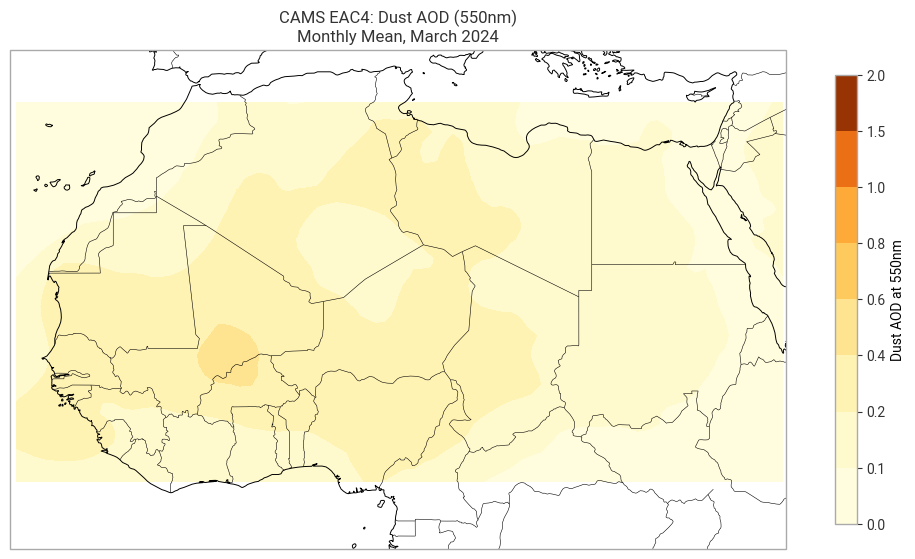

In [24]:
import cfgrib
import numpy as np

da_cf = cfgrib.open_dataset(str(dust_path))
print(da_cf)

# Monthly mean and plot
aod = da_cf['duaod550']
aod_mean = aod.mean(dim='time')

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(figsize=(10, 6),
    subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
levels = [0, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.5, 2.0]
im = ax.contourf(aod_mean.longitude, aod_mean.latitude, aod_mean,
    levels=levels, cmap='YlOrBr', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, label='Dust AOD at 550nm', shrink=0.8)
ax.set_title('CAMS EAC4: Dust AOD (550nm)\nMonthly Mean, March 2024')
ax.set_extent([-20, 40, 0, 35])
plt.tight_layout()
plt.show()

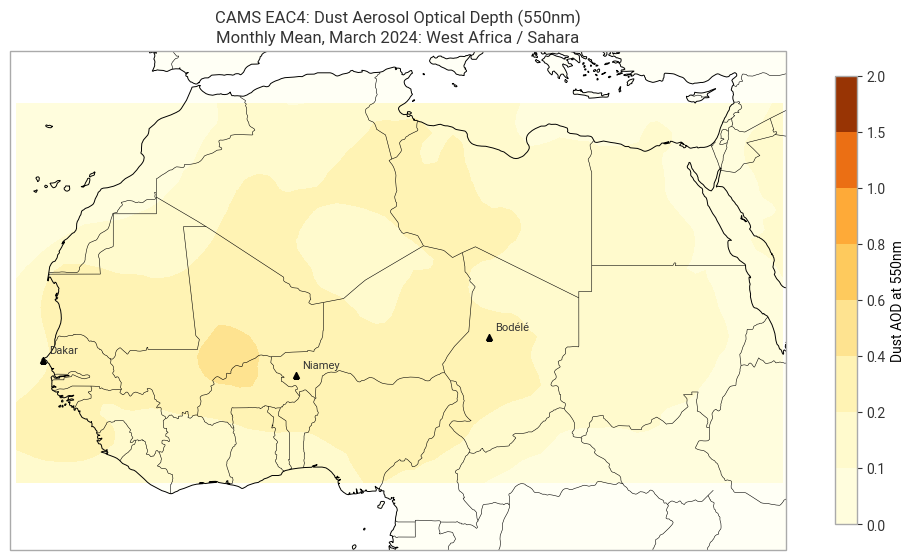

In [25]:
fig, ax = plt.subplots(figsize=(10, 6),
    subplot_kw={'projection': ccrs.PlateCarree()})

ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.LAND, facecolor='lightyellow', alpha=0.3)

# Use a dust-appropriate colourmap
levels = [0, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.5, 2.0]
im = ax.contourf(
    aod_mean.longitude, aod_mean.latitude, aod_mean,
    levels=levels, cmap='YlOrBr',
    transform=ccrs.PlateCarree()
)
plt.colorbar(im, ax=ax, label='Dust AOD at 550nm', shrink=0.8)

ax.set_title('CAMS EAC4: Dust Aerosol Optical Depth (550nm)\n'
    'Monthly Mean, March 2024: West Africa / Sahara', fontsize=12)
ax.set_extent([-20, 40, 0, 35])

# Add key locations
locations = {
    'Dakar': (-17.44, 14.69),
    'Niamey': (2.11, 13.51),
    'Bodélé': (17.0, 16.5),   # major dust source
}
for name, (lon, lat) in locations.items():
    ax.plot(lon, lat, 'k^', markersize=5, transform=ccrs.PlateCarree())
    ax.text(lon+0.5, lat+0.5, name, fontsize=8, transform=ccrs.PlateCarree())

plt.tight_layout()
plt.show()


## 4) Daily time series: dust event detection

Identifying individual dust events (AOD spikes) is key for
**health early warning**: issuing alerts when dust loading
exceeds safe thresholds.


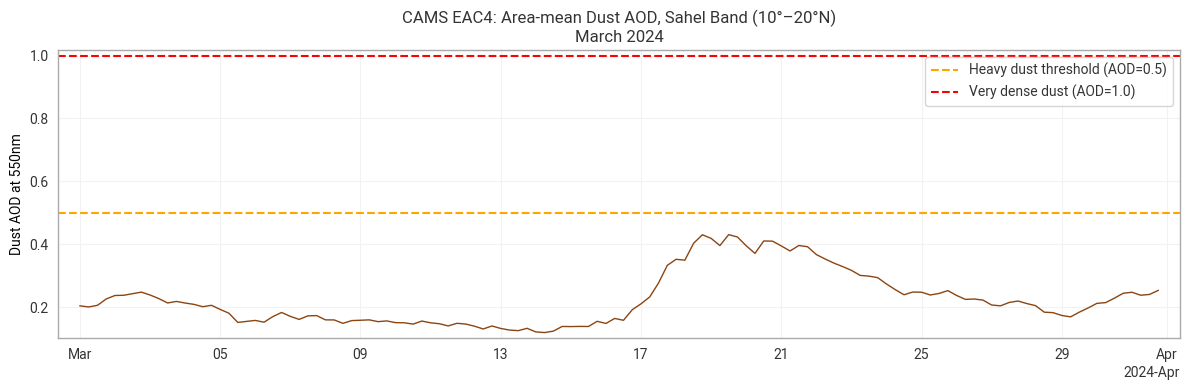

Timesteps with heavy dust loading (AOD > 0.5): 0


In [26]:
# Area-mean AOD time series over the Sahel band
# Select a latitude band: 10°N-20°N (core Sahel)
aod_sahel = aod.sel(
    latitude=slice(20, 10),  # note: latitude may be ordered N→S
).mean(dim=['latitude', 'longitude'])

fig, ax = plt.subplots(figsize=(12, 4))
aod_sahel.plot(ax=ax, color='saddlebrown', linewidth=1)
ax.axhline(0.5, color='orange', linestyle='--', label='Heavy dust threshold (AOD=0.5)')
ax.axhline(1.0, color='red',    linestyle='--', label='Very dense dust (AOD=1.0)')
ax.set_title('CAMS EAC4: Area-mean Dust AOD, Sahel Band (10°-20°N)\nMarch 2024')
ax.set_ylabel('Dust AOD at 550nm')
ax.set_xlabel('')
ax.legend()
plt.tight_layout()
plt.show()

# Identify timesteps exceeding threshold
heavy = aod_sahel.where(aod_sahel > 0.5, drop=True)
print(f'Timesteps with heavy dust loading (AOD > 0.5): {len(heavy)}')


## 5) CAMS near-real-time forecasts

EAC4 is a reanalysis (historical). For **operational early warning**,
CAMS also provides near-real-time atmospheric composition forecasts:

```python
# Near-real-time CAMS global forecast (5-day ahead)
ads.retrieve(
    'cams-global-atmospheric-composition-forecasts',
    {
        'variable': 'dust_aerosol_optical_depth_550nm',
        'date': 'today',
        'time': '00:00',
        'leadtime_hour': ['0', '6', '12', '24', '48', '72', '96', '120'],
        'area': [35, -20, 0, 40],
        'data_format': 'grib',
    },
    'cams_dust_forecast.grib'
)
```

This gives a 5-day dust forecast: directly usable for health advisories and aviation warnings.


## Take-home messages

- CAMS data is on **ADS**: same `cdsapi` client, different URL, separate free account needed
- EAC4 is the CAMS reanalysis: use it for historical dust event analysis and IbF model training
- CAMS near-real-time forecasts give 5-day dust outlooks: operational early warning
- The Bodélé Depression is a major dust source; Sahel dust seasons peak Feb-April
- AOD > 0.5 indicates heavy dust loading with health impacts
- Same workflow applies to other CAMS variables: PM2.5, ozone, fire radiative power

---

### Next steps
- Combine dust forecast with population exposure data for health impact estimation
- Use CAMS fire data for wildfire smoke early warning (Southern Africa dry season)
- Explore CAMS air quality forecasts at [atmosphere.copernicus.eu](https://atmosphere.copernicus.eu)

### Support
- ADS documentation: [ads.atmosphere.copernicus.eu](https://ads.atmosphere.copernicus.eu)
- CAMS data: [atmosphere.copernicus.eu/data](https://atmosphere.copernicus.eu/data)
- Questions: [support.ecmwf.int](https://support.ecmwf.int)
